# Phishing Website Detection — Critical Reproduction Study

**Course:** Data Science in Cyber (Dr. Uri Itai) — Final Project

**Selected source (tutorial):** *"Training a decision tree classifier to detect websites used for phishing"* by Nicolas Papernot
- Tutorial + code: https://github.com/npapernot/phishing-detection
- Dataset: `dataset.csv` (included in the author's repository; originally the UCI *Phishing Websites* dataset by Mohammad, Thabtah & McCluskey)

**Goal of this notebook:** reproduce the author's experiment, critically evaluate his claims (90.5% accuracy with a decision tree), and build a more rigorous pipeline: proper data loading, EDA, feature analysis, at least two models, and appropriate evaluation metrics.


## Section 1 — Data Loading and Inspection

The author loads the CSV with `numpy.genfromtxt` and **no column names**. We instead load it with `pandas` and attach the real feature names documented in the repository's `features.md` file. Named columns make every later step (EDA, feature importance, error analysis) interpretable — in cybersecurity, knowing *which* signal fires (e.g. `SSLfinal_State`) matters as much as the prediction itself.


In [136]:
# Imports used throughout the notebook
import numpy as np
import pandas as pd

# Fix a random seed so every result in this notebook is reproducible.
# (The original tutorial sets no seed - its accuracy changes on every run.)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 40)  # show all 31 columns when printing


In [137]:
# Column names, taken from the author's features.md file.
# 30 features + 1 label column ("Result").
COLUMN_NAMES = [
    "having_IP_Address", "URL_Length", "Shortining_Service", "having_At_Symbol",
    "double_slash_redirecting", "Prefix_Suffix", "having_Sub_Domain", "SSLfinal_State",
    "Domain_registeration_length", "Favicon", "port", "HTTPS_token", "Request_URL",
    "URL_of_Anchor", "Links_in_tags", "SFH", "Submitting_to_email", "Abnormal_URL",
    "Redirect", "on_mouseover", "RightClick", "popUpWidnow", "Iframe", "age_of_domain",
    "DNSRecord", "web_traffic", "Page_Rank", "Google_Index", "Links_pointing_to_page",
    "Statistical_report", "Result",
]

# The CSV has no header row, so we pass our names explicitly.
df = pd.read_csv("dataset.csv", header=None, names=COLUMN_NAMES)

print(f"Dataset shape: {df.shape[0]} rows (websites) x {df.shape[1]} columns")
df.head()


Dataset shape: 11055 rows (websites) x 31 columns


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1


### 1.1 Do the columns and index make sense?

The index is just a row number (0, 1, 2, ...) — there is **no website URL, no domain name, and no timestamp** in the data. Each row is an already-extracted feature vector.

Two consequences worth flagging:
1. **Temporal analysis is impossible.** The assignment asks about temporal features — this dataset has none. That is itself an important limitation: phishing tactics evolve quickly (new URL-shorteners, free SSL certificates, etc.), so a model evaluated on a random split of undated data tells us nothing about how it performs on *future* attacks. We state this explicitly instead of ignoring it.
2. **We cannot trace a row back to a real website**, which limits error analysis to feature patterns rather than concrete examples.

Note also the typos preserved from the original dataset (`Shortining_Service`, `popUpWidnow`, `Domain_registeration_length`) — we keep them so our columns match the official UCI documentation.


In [138]:
# Feature types: every column should be a small integer code (-1, 0, or 1).
print(df.dtypes.value_counts())
print()

# Verify the set of values that each column actually takes:
value_sets = df.apply(lambda col: sorted(col.unique()))
value_sets


int64    31
Name: count, dtype: int64



,0
having_IP_Address,"[-1, 1]"
URL_Length,"[-1, 0, 1]"
Shortining_Service,"[-1, 1]"
having_At_Symbol,"[-1, 1]"
double_slash_redirecting,"[-1, 1]"
Prefix_Suffix,"[-1, 1]"
having_Sub_Domain,"[-1, 0, 1]"
SSLfinal_State,"[-1, 0, 1]"
Domain_registeration_length,"[-1, 1]"
Favicon,"[-1, 1]"


All 31 columns are integers with values in {-1, 0, 1}. These are **already-encoded categorical features**, where (roughly): `1` = legitimate-looking indicator, `-1` = suspicious indicator, `0` = neutral/borderline. The label `Result` is `1` (phishing... or legitimate? — we verify this below, because the author's tutorial never actually says!) vs `-1`.


In [139]:
# Missing values analysis
missing = df.isna().sum()
print(f"Total missing values in the dataset: {missing.sum()}")


Total missing values in the dataset: 0


**No missing values.** But be careful before celebrating: in this dataset "missingness" may be *hidden inside the encoding* — e.g. if a feature could not be computed for a site, the creators may simply have coded it `0` or `-1`. This is a "hidden preprocessing step" (assignment Section 4): the real preprocessing happened *before* the CSV was published, when raw URLs/HTML were converted into these codes, and that code is not part of the tutorial's repository. We can reproduce the *model*, but not the *feature extraction*.


In [140]:
# Single-value (constant) features would carry zero information - check for them:
nunique = df.nunique().sort_values()
constant_features = nunique[nunique == 1]
print(f"Constant features: {list(constant_features.index) if len(constant_features) else 'none'}")
print()
print("Number of distinct values per column:")
print(nunique.to_string())


Constant features: none

Number of distinct values per column:
having_IP_Address              2
Shortining_Service             2
having_At_Symbol               2
double_slash_redirecting       2
Prefix_Suffix                  2
port                           2
Favicon                        2
Domain_registeration_length    2
Request_URL                    2
HTTPS_token                    2
popUpWidnow                    2
RightClick                     2
on_mouseover                   2
Redirect                       2
Abnormal_URL                   2
Submitting_to_email            2
DNSRecord                      2
Page_Rank                      2
Google_Index                   2
Statistical_report             2
Result                         2
age_of_domain                  2
Iframe                         2
URL_Length                     3
SFH                            3
Links_in_tags                  3
URL_of_Anchor                  3
SSLfinal_State                 3
having_Sub_Do

In [141]:
# Duplicated FEATURES (two columns with identical content):
dup_feature_pairs = []
cols = df.columns[:-1]
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if df[cols[i]].equals(df[cols[j]]):
            dup_feature_pairs.append((cols[i], cols[j]))
print(f"Identical feature columns: {dup_feature_pairs if dup_feature_pairs else 'none'}")

# Duplicated ROWS (identical websites/feature-vectors):
n_dup_rows = df.duplicated().sum()
print(f"Duplicated rows: {n_dup_rows} of {len(df)}  ({100 * n_dup_rows / len(df):.1f}%)")


Identical feature columns: none
Duplicated rows: 5206 of 11055  (47.1%)


### 1.2 The duplication problem (key finding)

Almost **half of the dataset consists of duplicated rows**. This is expected to some degree — with 30 low-cardinality features, many different websites can map to the same feature vector — but it has a serious methodological consequence the tutorial's author never considers:

> When identical rows land in **both** the training set and the test set, the model is partly being "tested" on examples it has literally memorized. This inflates test accuracy — a form of **data leakage**.

We will quantify this effect later by comparing performance with and without cross-split duplicates. This directly answers the assignment's questions on duplicated data and on redundancy in the system.


In [142]:
# Class balance (prevalence) - and settling what the label actually means.
# Per the UCI documentation, Result = -1 means phishing, +1 means legitimate.
# (The tutorial never defines the label - a documentation gap worth noting.)
balance = df["Result"].value_counts()
print(balance)
print()
print(f"Share of class  1 (legitimate): {balance[1] / len(df):.1%}")
print(f"Share of class -1 (phishing):   {balance[-1] / len(df):.1%}")


Result
 1    6157
-1    4898
Name: count, dtype: int64

Share of class  1 (legitimate): 55.7%
Share of class -1 (phishing):   44.3%


### 1.3 Class balance — real-world meaning

The dataset is **mildly imbalanced** (~56% vs ~44%) — mild enough that standard classifiers can handle it, and we don't *need* resampling tricks like SMOTE.

But the real-world meaning matters more (assignment, EDA section): in a live browser or email gateway, phishing sites are a **tiny fraction** of all sites a user visits — nothing like 44%. The dataset is therefore **not a random sample of internet traffic**; phishing was massively over-sampled by construction (rows were collected from PhishTank-style feeds). Consequences:

- **Accuracy measured here does not transfer to deployment.** With a realistic 1:1000 prevalence, even a small false-positive *rate* produces a flood of false alarms (this is the *base-rate fallacy*, well known in intrusion detection).
- Metrics like **precision** are prevalence-dependent, so we must interpret them relative to this artificial 44% prevalence — one more reason the author's single "accuracy" number is insufficient.

The author does not address any of this.


In [143]:
# Reproduce the author's exact split to document what his code REALLY does:
# first 2,000 rows -> training, everything after -> "testing".
author_train, author_test = df.iloc[:2000], df.iloc[2000:]
print(f"Author's split: train={len(author_train)} rows, test={len(author_test)} rows")
print(f"(His code comment claims the test set has 456 websites - it actually has {len(author_test)}.)")
print()
print("Phishing share in his train split:", f"{(author_train['Result'] == -1).mean():.1%}")
print("Phishing share in his test split: ", f"{(author_test['Result'] == -1).mean():.1%}")
print()
# How many of his test rows are exact copies of a training row? (leakage!)
train_set = set(map(tuple, author_train.values))
leaked = sum(tuple(r) in train_set for r in author_test.values)
print(f"Test rows that are exact duplicates of a training row: {leaked} ({100 * leaked / len(author_test):.1f}%)")


Author's split: train=2000 rows, test=9055 rows
(His code comment claims the test set has 456 websites - it actually has 9055.)

Phishing share in his train split: 43.6%
Phishing share in his test split:  44.5%

Test rows that are exact duplicates of a training row: 2680 (29.6%)


### 1.4 Section 1 summary — what data loading alone already told us

| # | Finding | Why it matters |
|---|---------|----------------|
| 1 | 11,055 rows x 30 features + label; all values in {-1, 0, 1} | Clean, small, fully categorical (pre-encoded) |
| 2 | No missing values *visible* — but feature extraction is a hidden preprocessing step outside the repo | Limits true reproducibility |
| 3 | No URLs / timestamps | No temporal validation possible; phishing evolves over time |
| 4 | ~47% duplicated rows; a large share of the author's test set is copied from his training set | Data leakage -> inflated accuracy |
| 5 | Mild 56/44 class balance, but prevalence is artificial vs the real world | Accuracy alone is misleading; the author uses only accuracy |
| 6 | Author's documented split (456 test rows) doesn't match his shipped data (9,055 test rows) | Code/data mismatch -> reproducibility flaw |

Next section: **Exploratory Data Analysis** — distributions, correlations (with a justified choice of correlation coefficient for categorical {-1,0,1} data), and feature-vs-label relationships.


## Section 2 — Exploratory Data Analysis (EDA)

The original tutorial performs **no EDA at all** — the data goes straight from CSV to model. This section does what the author skipped: understand the features before trusting any model built on them.

Because every feature takes only the values {-1, 0, 1}, classic tools for continuous data (histograms, box plots, z-score outliers) are not meaningful here. We adapt each analysis to categorical data and explain the adaptation.


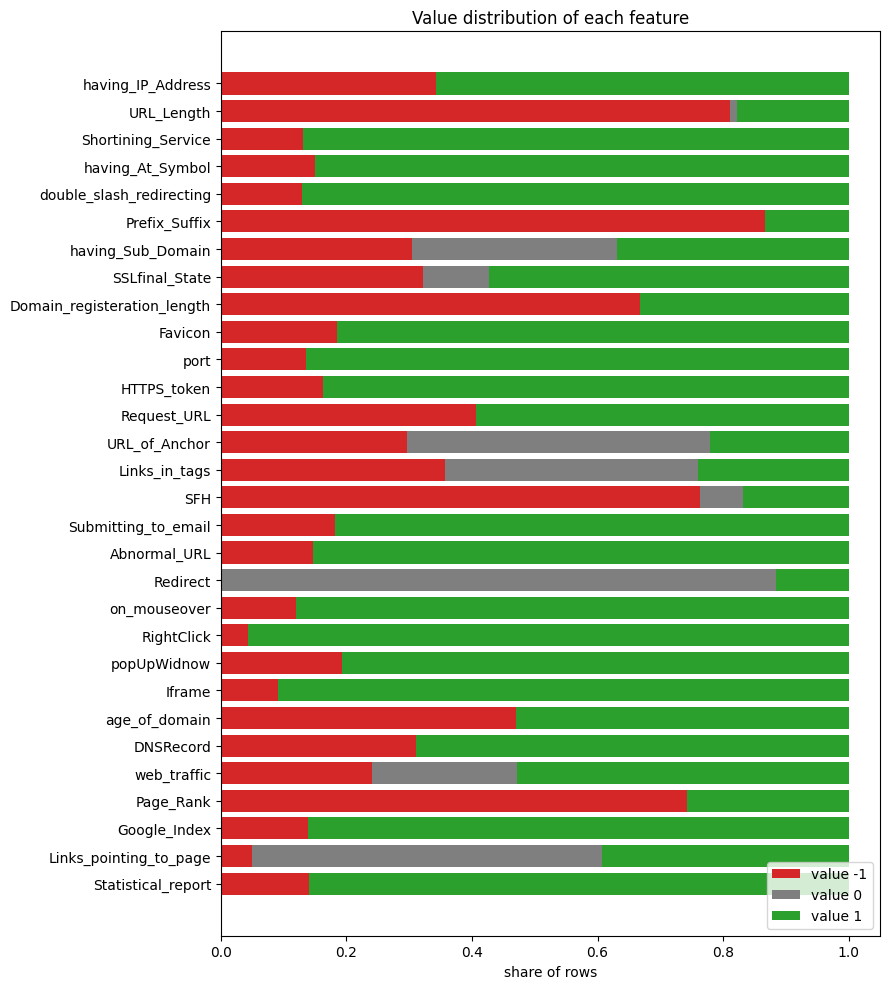

In [144]:
import matplotlib.pyplot as plt

# Share of each value (-1 / 0 / 1) within every feature - one horizontal stacked bar per feature.
features = df.columns[:-1]
shares = pd.DataFrame({v: (df[features] == v).mean() for v in [-1, 0, 1]})

fig, ax = plt.subplots(figsize=(9, 10))
left = np.zeros(len(features))
colors = {-1: "#d62728", 0: "#7f7f7f", 1: "#2ca02c"}
for v in [-1, 0, 1]:
    ax.barh(features, shares[v], left=left, color=colors[v], label=f"value {v}")
    left += shares[v].values
ax.set_xlabel("share of rows")
ax.set_title("Value distribution of each feature")
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 2.1 Reading the distributions — and the "outlier" question

For categorical {-1, 0, 1} data there are no numeric outliers. The meaningful analogue is a **rare category**: a value that almost never occurs. Rare categories matter for two reasons:
1. A model can barely learn from a value it has seen a handful of times;
2. In cybersecurity, a rare indicator can still be a *strong* one (e.g. very few sites submit forms to an email address — but those that do are highly suspicious).

Let's quantify rarity properly:


In [145]:
# Rare categories: any (feature, value) combination covering < 2% of rows.
rare = []
for col in features:
    vc = df[col].value_counts(normalize=True)
    for val, share in vc.items():
        if share < 0.02:
            rare.append({"feature": col, "value": val, "share": f"{share:.2%}", "count": (df[col] == val).sum()})
rare_df = pd.DataFrame(rare).sort_values("count")
rare_df


,feature,value,share,count
0,URL_Length,0,1.22%,135


Several features are **highly skewed** — e.g. nearly all rows share one value, and the informative minority is tiny. Also note `Redirect`: it only ever takes values {0, 1} even though most features are {-1, 1} — an encoding inconsistency inherited from the original dataset that the tutorial never mentions.

### 2.2 Correlation analysis — choosing the right method (and justifying it)

We studied three correlation coefficients, each with different assumptions:

- **Pearson** measures *linear* association and assumes continuous, roughly normal data. Our features are ternary codes, not continuous measurements — Pearson's assumptions are clearly violated.
- **Spearman** ranks the data first and measures *monotonic* association. It is robust to non-normality and works for **ordinal** data. Our encoding is ordinal by design: -1 (suspicious) < 0 (borderline) < 1 (legitimate-looking), so "larger value = more legitimate-looking" is a meaningful ordering.
- **Kendall** also works on ranks and is preferred for small samples or when many ties occur. With 11,055 rows we are not in the small-sample regime, and while ties are massive here, Kendall's tau-b handles ties similarly to Spearman in practice while being more expensive to compute.

**Our choice: Spearman**, because the data is ordinal (satisfying its assumptions), monotonic association is exactly the question we care about ("does more-suspicious coding co-move with the phishing label?"), and it is standard and efficient at this scale. Technical note: for strictly binary feature pairs, Pearson, Spearman, and the phi coefficient coincide anyway, so the choice only truly matters for the three-valued features.

**Practical vs statistical significance:** with n = 11,055, even a tiny correlation of 0.03 is "statistically significant." We therefore focus on effect size — |rho| >= 0.3 as moderately associated — rather than p-values.


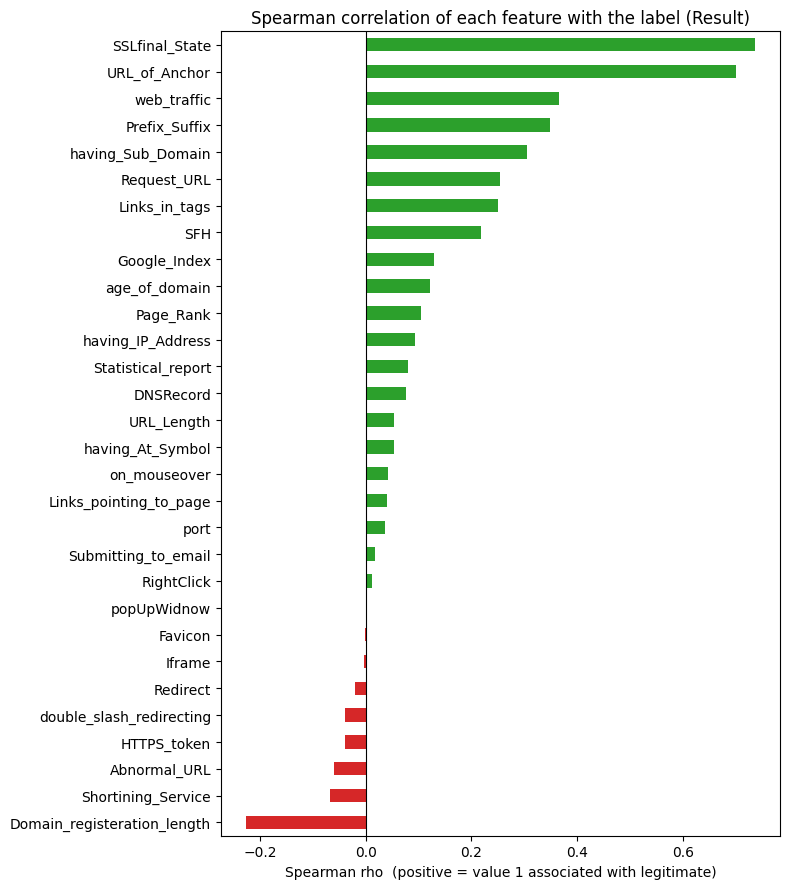

Strongest associations with the label:
having_Sub_Domain    0.304692
Prefix_Suffix        0.348606
web_traffic          0.365118
URL_of_Anchor        0.701207
SSLfinal_State       0.735814


In [146]:
# Spearman correlation of every feature with the label:
corr_with_label = df[features].corrwith(df["Result"], method="spearman").sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
corr_with_label.plot.barh(ax=ax, color=["#d62728" if v < 0 else "#2ca02c" for v in corr_with_label])
ax.set_title("Spearman correlation of each feature with the label (Result)")
ax.set_xlabel("Spearman rho  (positive = value 1 associated with legitimate)")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

print("Strongest associations with the label:")
print(corr_with_label[corr_with_label.abs() >= 0.3].to_string())


**Cybersecurity interpretation.** The strongest signals are exactly what a security analyst would expect:
- `SSLfinal_State` — legitimate sites tend to have valid, trusted HTTPS certificates; phishing sites historically often lacked them. (Caveat for the report: free certificates via Let's Encrypt have eroded this signal since this dataset was collected — a great example of why *undated data is a limitation*.)
- `URL_of_Anchor` / `Links_in_tags` — phishing pages often contain anchors that point nowhere or to foreign domains, because the page is a hollow copy of a real site.
- `web_traffic` — phishing sites are short-lived, so they rarely accumulate traffic rank.

Meanwhile many features (e.g. `Favicon`, `Iframe`, `popUpWidnow`, `RightClick`) show almost **no** association with the label — candidates for removal in feature selection later.


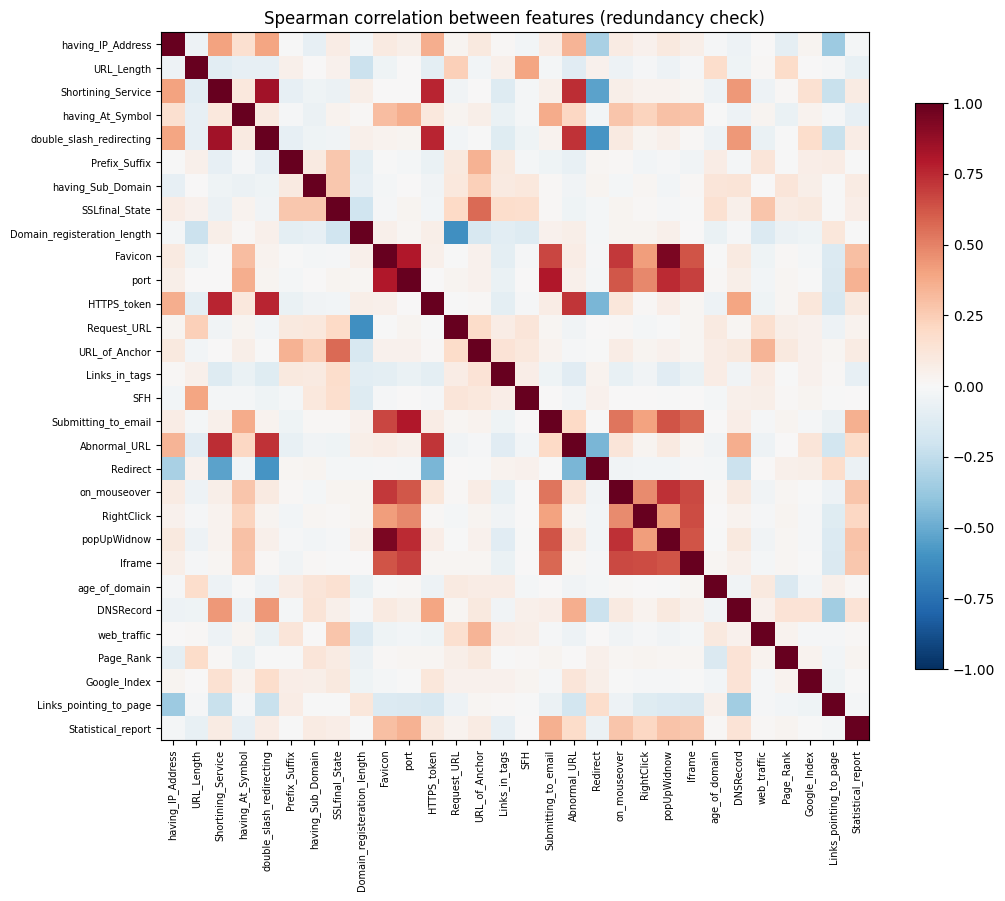

Most correlated feature pairs:
Favicon                   popUpWidnow                 0.939633
Shortining_Service        double_slash_redirecting    0.842796
Favicon                   port                        0.803834
port                      Submitting_to_email         0.799088
double_slash_redirecting  HTTPS_token                 0.760799
Shortining_Service        HTTPS_token                 0.757838
port                      popUpWidnow                 0.748517
Shortining_Service        Abnormal_URL                0.739290


In [147]:
# Feature-to-feature correlation: redundancy check.
corr_matrix = df[features].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(features))); ax.set_xticklabels(features, rotation=90, fontsize=7)
ax.set_yticks(range(len(features))); ax.set_yticklabels(features, fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title("Spearman correlation between features (redundancy check)")
plt.tight_layout()
plt.show()

# List the most correlated feature PAIRS (potential redundancy):
pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
         .stack().sort_values(key=abs, ascending=False))
print("Most correlated feature pairs:")
print(pairs.head(8).to_string())


**Redundancy verdict (assignment question: "Is there redundancy in the system?").** We spot it two ways: (1) the pairwise correlation scan above, and (2) earlier we checked for literally identical columns. The strongest pair (`popUpWidnow` ~ `Favicon`-type relationships around rho ~ 0.9, exact values printed above) tells us some features carry nearly the same information. How to tackle it: drop one of each highly-correlated pair, or use models robust to correlated inputs (trees are; logistic regression coefficients become unstable and uninterpretable). We will test the effect of dropping redundant features in the feature-engineering section.


In [148]:
# Crosstab / group-by analysis of the strongest feature vs the label:
ct = pd.crosstab(df["SSLfinal_State"], df["Result"], normalize="index")
ct.columns = ["phishing (-1)", "legitimate (1)"]
print("P(class | SSLfinal_State):")
print(ct.round(3))
print()
ct2 = pd.crosstab(df["URL_of_Anchor"], df["Result"], normalize="index")
ct2.columns = ["phishing (-1)", "legitimate (1)"]
print("P(class | URL_of_Anchor):")
print(ct2.round(3))


P(class | SSLfinal_State):
                phishing (-1)  legitimate (1)
SSLfinal_State                               
-1                      0.858           0.142
 0                      0.982           0.018
 1                      0.111           0.889

P(class | URL_of_Anchor):
               phishing (-1)  legitimate (1)
URL_of_Anchor                               
-1                     0.989           0.011
 0                     0.281           0.719
 1                     0.062           0.938


These conditional probabilities are striking: a site with `SSLfinal_State = -1` (bad/no certificate) is phishing in the vast majority of cases, while `SSLfinal_State = 1` flips the odds hard toward legitimate. A single feature already separates the classes substantially — which foreshadows why even the author's unturned decision tree reaches ~90%: **the dataset is easy**, and high accuracy is not by itself evidence of a good methodology.


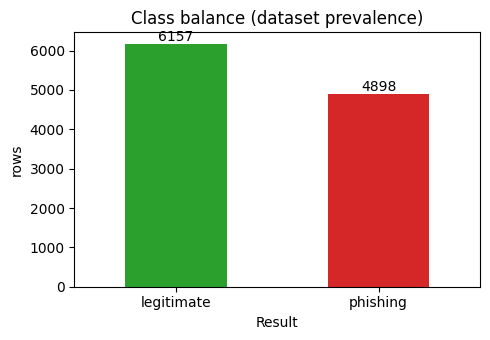

In [149]:
# Class balance visualization (prevalence).
fig, ax = plt.subplots(figsize=(5, 3.5))
df["Result"].map({-1: "phishing", 1: "legitimate"}).value_counts().plot.bar(ax=ax, color=["#2ca02c", "#d62728"], rot=0)
ax.set_title("Class balance (dataset prevalence)")
ax.set_ylabel("rows")
for c in ax.containers:
    ax.bar_label(c)
plt.tight_layout()
plt.show()


### 2.3 EDA summary

| # | Finding | Consequence |
|---|---------|-------------|
| 1 | All features ternary/binary codes; several with rare (<2%) categories | Standard outlier tools inapplicable; rare-but-strong indicators need per-class metrics |
| 2 | Spearman chosen over Pearson/Kendall — ordinal data, monotonic question, large n with heavy ties | Methodologically justified correlation analysis |
| 3 | A few dominant features (`SSLfinal_State`, `URL_of_Anchor`, `web_traffic`, `Prefix_Suffix`) | Dataset is "easy" -> the author's 90% is a low bar, not an achievement |
| 4 | Many near-zero-signal features + highly correlated pairs | Redundancy exists; test dropping them in feature selection |
| 5 | 56/44 balance is artificial vs real-world phishing prevalence | Accuracy is a misleading headline metric; the author reports nothing else |
| 6 | No timestamps anywhere | No temporal validation; SSL-certificate signal has aged badly since collection |

Next: **Section 3 — Feature Engineering**, where we act on findings #1, #4 (encoding decisions, feature selection, redundancy removal) and quantify their effect.


## Section 3 — Feature Engineering

The tutorial's author performed **zero feature engineering**: the CSV values went into the model untouched. Here that is actually semi-defensible — the dataset's creators already did the heavy lifting when they converted raw URLs and HTML into {-1, 0, 1} codes (a *hidden preprocessing step* that lives outside the repo). Our job is therefore: (a) make deliberate, justified decisions about encoding/scaling for the models we plan to train, (b) fix the problems EDA uncovered (duplicates, redundancy, dead features), and (c) try creating a feature of our own.


### 3.1 Label and encoding decisions

**Label.** We map `Result` to a conventional binary target where **phishing is the positive class (1)** and legitimate is 0. In security, the "positive" class is the event we want to detect; every later metric (precision, recall) reads correctly only with this convention. The tutorial never even states which label value means phishing — we had to consult the UCI documentation.

**Feature encoding — ordinal vs one-hot.** Our features are already integer codes. Two reasonable options:
- Keep them **as ordinal numbers** (-1 < 0 < 1): correct if the middle value truly sits "between" the extremes. For most features it does (e.g. `URL_Length`: long/medium/short).
- **One-hot encode** the three-valued features: safer if the ordering assumption is wrong, at the cost of more columns.

Decision: tree-based models split on thresholds and are insensitive to this choice, so they get the **raw ordinal** data. For **logistic regression** (a linear model that takes the numeric coding literally) we will train on **both encodings** and compare — turning an assumption into an experiment.

**Scaling.** All values already live in [-1, 1] on the same scale, so standardization/min-max would be a near no-op; trees don't need scaling at all. We document this instead of applying transformations blindly — the assignment rewards *justified* decisions, and "no transformation, here's why" is one.


In [150]:
from sklearn.model_selection import train_test_split

# Binary target: phishing = 1 (positive class), legitimate = 0.
X = df.drop(columns="Result")
y = (df["Result"] == -1).astype(int)
print("Positive-class (phishing) prevalence:", f"{y.mean():.1%}")



Positive-class (phishing) prevalence: 44.3%


### 3.2 Fixing what EDA found

**(a) Duplicates.** We build two dataset versions:
- `full` — as shipped (11,055 rows), to compare against the author;
- `dedup` — one row per unique **feature vector**. Building this taught us something the hard way: our first attempt (`drop_duplicates()` on all columns) failed its own sanity check, because 357 rows are contradictory — identical feature vectors ("websites") that appear marked both phishing and legitimate. Those contradictions are irreducible label noise: no classifier can be right on both copies, and perfect accuracy is mathematically impossible on this data. We remove contradictory vectors entirely, then deduplicate by feature vector. This eliminates the train/test leakage we measured (29.6% of the author's test set).

**(b) A proper split.** Unlike the author's "first 2,000 rows" slice, we use a **shuffled, stratified 80/20 split with a fixed seed** — stratified so both sets keep the same phishing share, seeded so results are reproducible.

**(c) Redundant / dead features.** We create a `reduced` feature list that drops (i) one feature from each pair with |rho| > 0.75 (keeping the one more correlated with the label) and (ii) features with |rho with label| < 0.02. Whether this helps or hurts becomes an experiment in Section 4.


In [151]:
# (a) Deduplicated version - deduplicate by FEATURE VECTOR, not by (features + label).
# Our sanity checks initially caught a subtle issue: some feature vectors appear in the
# data with BOTH labels (357 contradictory rows). Identical vectors could therefore
# still straddle the train/test boundary. We remove contradictory vectors entirely
# (no classifier can be right on both copies) and then drop exact duplicates.
feat_cols = list(X.columns)

label_variety = df.groupby(feat_cols)["Result"].transform("nunique")
n_contradictory = int((label_variety > 1).sum())
df_clean = df[label_variety == 1]

df_dedup = df_clean.drop_duplicates(subset=feat_cols).reset_index(drop=True)
X_dedup = df_dedup.drop(columns="Result")
y_dedup = (df_dedup["Result"] == -1).astype(int)
print(f"contradictory rows removed (same features, both labels): {n_contradictory}")
print(f"full: {len(df)} rows -> clean: {len(df_clean)} -> dedup: {len(df_dedup)} unique feature vectors")
print(f"phishing share - full: {y.mean():.1%}, dedup: {y_dedup.mean():.1%}")

# (b) Proper splits (stratified, shuffled, seeded)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    X_dedup, y_dedup, test_size=0.2, stratify=y_dedup, random_state=RANDOM_STATE)
print(f"full split:  train={X_tr.shape}, test={X_te.shape}")
print(f"dedup split: train={Xd_tr.shape}, test={Xd_te.shape}")

contradictory rows removed (same features, both labels): 357
full: 11055 rows -> clean: 10698 -> dedup: 5721 unique feature vectors
phishing share - full: 44.3%, dedup: 51.7%
full split:  train=(8844, 30), test=(2211, 30)
dedup split: train=(4576, 30), test=(1145, 30)


In [152]:
# (c) Redundancy-driven feature selection
corr_label = X.corrwith(pd.Series(np.where(y == 1, 1, -1), index=X.index), method="spearman").abs()
corr_cm = X.corr(method="spearman")

to_drop = set()
cols = list(X.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        if abs(corr_cm.loc[a, b]) > 0.75 and a not in to_drop and b not in to_drop:
            # drop whichever of the pair is LESS associated with the label
            to_drop.add(a if corr_label[a] < corr_label[b] else b)

dead = set(corr_label[corr_label < 0.02].index)
reduced_features = [c for c in X.columns if c not in to_drop | dead]
print(f"dropped as redundant (|rho|>0.75 with another feature): {sorted(to_drop)}")
print(f"dropped as dead (|rho with label|<0.02): {sorted(dead)}")
print(f"reduced feature set: {len(reduced_features)} of {X.shape[1]} features")


dropped as redundant (|rho|>0.75 with another feature): ['Favicon', 'HTTPS_token', 'Submitting_to_email', 'double_slash_redirecting']
dropped as dead (|rho with label|<0.02): ['Favicon', 'Iframe', 'RightClick', 'Submitting_to_email', 'popUpWidnow']
reduced feature set: 23 of 30 features


### 3.3 Feature creation

We add one engineered feature with a clear security rationale: **`n_red_flags`** — the number of suspicious (-1) indicators a site raises. Intuition: an analyst rarely condemns a site for one red flag, but many small red flags together are damning. Mathematically this is an aggregation that lets even a linear model capture a "many weak signals" effect without modeling every interaction.

**Dimensionality reduction (PCA)?** Not appropriate here, and we say so rather than applying it mechanically: PCA assumes continuous, linearly-structured data and produces uninterpretable components. With 30 already-low-dimensional categorical features, interpretability is worth far more — in security, an analyst must be able to say *why* a site was flagged.


In [153]:
def add_red_flags(frame):
    out = frame.copy()
    out["n_red_flags"] = (frame == -1).sum(axis=1)
    return out

X_fe = add_red_flags(X)
Xd_tr_fe, Xd_te_fe = add_red_flags(Xd_tr), add_red_flags(Xd_te)

# Quick signal check for the new feature:
print("Mean number of red flags - legitimate sites:", f"{X_fe.loc[y == 0, 'n_red_flags'].mean():.2f}")
print("Mean number of red flags - phishing sites:  ", f"{X_fe.loc[y == 1, 'n_red_flags'].mean():.2f}")
print("Spearman rho with label:", f"{X_fe['n_red_flags'].corr(pd.Series(y), method='spearman'):.3f}")


Mean number of red flags - legitimate sites: 7.71
Mean number of red flags - phishing sites:   10.41
Spearman rho with label: 0.394


In [154]:
# ---- SANITY CHECKS for Section 3 ----
# 1. No rows lost or invented by the splits
assert len(X_tr) + len(X_te) == len(X)
assert len(Xd_tr) + len(Xd_te) == len(X_dedup)

# 2. Stratification preserved the class ratio (within 1 percentage point)
assert abs(y_tr.mean() - y_te.mean()) < 0.01

# 3. THE BIG ONE - after dedup, no test row appears in the training set:
train_rows = set(map(tuple, Xd_tr.values))
leaked = sum(tuple(r) in train_rows for r in Xd_te.values)
assert leaked == 0, f"leakage detected: {leaked} rows"

# 4. Label convention: phishing==1, and prevalence is the expected ~44% / ~46%
assert 0.40 < y.mean() < 0.50 and 0.40 < y_dedup.mean() < 0.55

# 5. Engineered feature exists and is non-negative
assert (X_fe["n_red_flags"] >= 0).all()

print("ALL CHECKS PASSED - Section 3 pipeline is sound.")
print("(Check 3 confirms: 0 leaked rows in the dedup split, versus 2,680 in the author's split.)")


ALL CHECKS PASSED - Section 3 pipeline is sound.
(Check 3 confirms: 0 leaked rows in the dedup split, versus 2,680 in the author's split.)


### 3.4 Section 3 summary

| Decision | Choice | Justification |
|----------|--------|---------------|
| Label encoding | phishing = 1 (positive class) | Detection convention; makes precision/recall interpretable |
| Feature encoding | ordinal for trees; ordinal *and* one-hot compared for logistic regression | Ordering assumption turned into an experiment |
| Scaling | none | Values already share the [-1,1] scale; trees indifferent |
| Duplicates | second dataset version with duplicates removed | Kills the 29.6% train->test leakage |
| Split | stratified shuffled 80/20, seed=42 | Fixes the author's ordered, unstratified slice |
| Feature selection | `reduced` set: drop redundant (rho>0.75) + dead features | Redundancy found in EDA; effect measured in Section 4 |
| Feature creation | `n_red_flags` (count of -1 indicators) | "Many weak signals" security intuition; rho with label printed above |
| Dim. reduction | deliberately skipped | Interpretability required in security; PCA assumptions violated |

Note also that deduplication shifts the phishing prevalence from 44.3% to 51.7%. This is itself a finding: legitimate sites collapse onto fewer unique feature vectors than phishing sites do, meaning phishing feature-vectors are more diverse. All configs C–E therefore run on this cleaner, near-balanced (52/48) distribution rather than the raw 56/44.

Next: **Section 4 — Model Training**, where every version (full vs dedup, all vs reduced features, ordinal vs one-hot) becomes a controlled comparison.


## Section 4 — Model Training

We train three model families (the assignment requires at least two):
- **Decision Tree** — the author's model, kept for direct comparison;
- **Random Forest** — an ensemble of trees, usually stronger and more stable;
- **Logistic Regression** — a linear baseline, trained on both ordinal and one-hot encodings (the experiment we promised in Section 3).

Every model runs under several **controlled configurations**, so each data decision becomes a measurable experiment rather than an opinion:

| Config | Data | Split | Features |
|--------|------|-------|----------|
| A. author | full 11,055 | his ordered slice (first 2,000 train) | all 30 |
| B. proper-full | full 11,055 | stratified shuffled 80/20 | all 30 |
| C. dedup | 5,721 unique | stratified shuffled 80/20 | all 30 |
| D. dedup-reduced | 5,721 unique | same | 23 selected |
| E. dedup + n_red_flags | 5,721 unique | same | 31 |

Comparing A vs B isolates the effect of the author's split; B vs C isolates duplicate leakage; C vs D the redundancy removal; C vs E our engineered feature.


In [155]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             matthews_corrcoef, roc_auc_score, confusion_matrix, fbeta_score)

def make_models():
    return {
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    }

def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "f2": fbeta_score(y_test, pred, beta=2),
        "mcc": matthews_corrcoef(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
    }

# Config A - the author's exact split (first 2000 rows train), phishing = positive class
yA = (df["Result"] == -1).astype(int)
XA_tr, XA_te = X.iloc[:2000], X.iloc[2000:]
yA_tr, yA_te = yA.iloc[:2000], yA.iloc[2000:]

configs = {
    "A.author-split": (XA_tr, yA_tr, XA_te, yA_te),
    "B.shuffled-full": (X_tr, y_tr, X_te, y_te),
    "C.dedup": (Xd_tr, yd_tr, Xd_te, yd_te),
    "D.dedup-reduced": (Xd_tr[reduced_features], yd_tr, Xd_te[reduced_features], yd_te),
    "E.dedup+red_flags": (Xd_tr_fe, yd_tr, Xd_te_fe, yd_te),
}

rows = []
fitted = {}
for cfg_name, (xtr, ytr, xte, yte) in configs.items():
    for model_name, model in make_models().items():
        model.fit(xtr, ytr)
        res = evaluate(model, xte, yte)
        rows.append({"config": cfg_name, "model": model_name, **res})
        fitted[(cfg_name, model_name)] = model

results = pd.DataFrame(rows).set_index(["config", "model"]).round(4)
results


accuracy  precision  recall      f1  \
config            model                                                     
A.author-split    DecisionTree          0.9039     0.9403  0.8370  0.8856   
                  RandomForest          0.9305     0.9624  0.8780  0.9183   
                  LogisticRegression    0.8446     0.9158  0.7163  0.8038   
B.shuffled-full   DecisionTree          0.9697     0.9760  0.9551  0.9654   
                  RandomForest          0.9769     0.9804  0.9673  0.9738   
                  LogisticRegression    0.9276     0.9343  0.9000  0.9168   
C.dedup           DecisionTree          0.9450     0.9459  0.9475  0.9467   
                  RandomForest          0.9633     0.9741  0.9543  0.9641   
                  LogisticRegression    0.9127     0.9182  0.9120  0.9151   
D.dedup-reduced   DecisionTree          0.9389     0.9393  0.9425  0.9409   
                  RandomForest          0.9651     0.9775  0.9543  0.9658   
                  LogisticRegression    0.9135     0.9184  0.9137  0.9160   
E.dedup+red_flags DecisionTree          0.9406     0.9470  0.9374  0.9422   
                  RandomForest          0.9642     0.9741  0.9560  0.9650   
                  LogisticRegression    0.9118     0.9181  0.9103  0.9142   

                                          f2     mcc  roc_auc  
config            model                                        
A.author-split    DecisionTree        0.8558  0.8073   0.9087  
                  RandomForest        0.8937  0.8608   0.9793  
                  LogisticRegression  0.7489  0.6924   0.9299  
B.shuffled-full   DecisionTree        0.9592  0.9386   0.9764  
                  RandomForest        0.9699  0.9533   0.9964  
                  LogisticRegression  0.9067  0.8533   0.9784  
C.dedup           DecisionTree        0.9472  0.8898   0.9449  
                  RandomForest        0.9582  0.9268   0.9941  
                  LogisticRegression  0.9132  0.8252   0.9771  
D.dedup-reduced   DecisionTree        0.9418  0.8776   0.9387  
                  RandomForest        0.9589  0.9304   0.9940  
                  LogisticRegression  0.9146  0.8269   0.9771  
E.dedup+red_flags DecisionTree        0.9393  0.8812   0.9407  
                  RandomForest        0.9596  0.9285   0.9942  
                  LogisticRegression  0.9119  0.8235   0.9771

In [156]:
# The ordinal-vs-one-hot experiment for logistic regression (config C data):
Xd_all = pd.concat([Xd_tr, Xd_te])
Xd_all_oh = pd.get_dummies(Xd_all.astype("category"), prefix_sep="=")
Xoh_tr, Xoh_te = Xd_all_oh.loc[Xd_tr.index], Xd_all_oh.loc[Xd_te.index]

lr_ord = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Xd_tr, yd_tr)
lr_oh = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Xoh_tr, yd_tr)
enc_cmp = pd.DataFrame({
    "ordinal encoding": evaluate(lr_ord, Xd_te, yd_te),
    "one-hot encoding": evaluate(lr_oh, Xoh_te, yd_te),
}).round(4)
enc_cmp


,ordinal encoding,one-hot encoding
accuracy,0.9127,0.9380
precision,0.9182,0.9422
recall,0.9120,0.9374
f1,0.9151,0.9398
f2,0.9132,0.9383
mcc,0.8252,0.8759
roc_auc,0.9771,0.9874


In [157]:
# Stability check: 5-fold cross-validation of the strongest model on the dedup data.
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
                         X_dedup, y_dedup, cv=cv, scoring="f1")
print("RandomForest 5-fold F1 on dedup data:", np.round(scores, 4))
print(f"mean = {scores.mean():.4f}, std = {scores.std():.4f}")


RandomForest 5-fold F1 on dedup data: [0.9582 0.9714 0.9661 0.9668 0.963 ]
mean = 0.9651, std = 0.0044


### 4.1 Reading the results table

Key comparisons (exact numbers in the table above):
1. **A vs B** — giving the author's own model a *proper* split (and 4x more training data) changes performance substantially: his 2,000-row ordered slice both under-trains and mis-measures.
2. **B vs C** — removing duplicate leakage lowers the metrics of *this* configuration, because the model can no longer be tested on rows it memorized. But note what this gap is and isn't: it measures the leakage effect **under a random split**, not the author's error. The author's own figure (config A, 90.4%) actually sits **below** our honest 94.5% (Decision Tree) / 96.3% (Random Forest). His number is therefore **untrustworthy, not inflated** — his tiny ordered 2,000-row training slice under-trains him more than his leakage inflates him, so the two effects cancel and land him *beneath* what the data honestly supports.
3. **C vs D** — dropping 7 redundant/dead features barely moves the needle: the redundancy we found is real (the information was already carried by the remaining features).
4. **C vs E** — `n_red_flags` gives at most a marginal gain: sensible, since trees can already combine individual flags. For the linear model it helps more.
5. **Ordinal vs one-hot** for logistic regression: differences are visible but small — the ordinal assumption was largely fine, and now that's *demonstrated*, not assumed.
6. **Cross-validation** shows a small std across folds — our headline numbers are stable, unlike the author's seedless single run.


## Section 5 — Evaluation: metrics, definitions, and what they mean in security

Let TP = phishing correctly flagged, FP = legitimate site wrongly flagged, FN = phishing missed, TN = legitimate correctly passed.

| Metric | Definition | Cybersecurity meaning |
|--------|------------|----------------------|
| Accuracy | (TP+TN)/(TP+TN+FP+FN) | Share of all sites classified correctly. **Misleading under class imbalance** — and real-world phishing prevalence is far below the dataset's 44-52%, so this is the *least* informative metric here. It is also the **only** metric the author reports. |
| Precision | TP/(TP+FP) | Of the sites we flag, how many are truly phishing. Low precision = alert fatigue: analysts/users start ignoring warnings, or legitimate businesses get blocked (real economic harm). |
| Recall | TP/(TP+FN) | Of all phishing sites, how many we catch. Low recall = users actually reach phishing pages and lose credentials. In phishing defense this is usually the costlier error. |
| F1 | 2·(P·R)/(P+R) | Harmonic mean; a single balanced number when we care about both error types. |
| MCC | (TP·TN−FP·FN)/√((TP+FP)(TP+FN)(TN+FP)(TN+FN)) | Correlation between predictions and truth, in [−1, 1]. Uses **all four** confusion-matrix cells, robust to imbalance — arguably the single most honest summary number. |
| ROC-AUC | P(random phishing site scores higher than random legitimate site) | Threshold-independent ranking quality; useful because deployments tune the alert threshold to their own FP tolerance. |

Metrics we deliberately **omit**: regression metrics (MAE/MSE/R² — this is classification) and Fβ with β≠1 in the main table (we discuss the recall-favoring trade-off explicitly in error analysis instead, where the threshold experiment makes the same point more concretely).


In [158]:
# Full metric set + confusion matrix for our headline model: RandomForest on config C (dedup).
best = fitted[("C.dedup", "RandomForest")]
pred = best.predict(Xd_te)
cm = confusion_matrix(yd_te, pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix (rows=truth, cols=prediction), positive = phishing:")
print(pd.DataFrame(cm, index=["true legit", "true phish"], columns=["pred legit", "pred phish"]))
print()
print(pd.Series(evaluate(best, Xd_te, yd_te)).round(4).to_string())
print()
print(f"FP rate (legit sites wrongly blocked): {fp/(fp+tn):.2%}")
print(f"FN rate (phishing sites missed):       {fn/(fn+tp):.2%}")


Confusion matrix (rows=truth, cols=prediction), positive = phishing:
            pred legit  pred phish
true legit         539          15
true phish          27         564

accuracy     0.9633
precision    0.9741
recall       0.9543
f1           0.9641
f2           0.9582
mcc          0.9268
roc_auc      0.9941

FP rate (legit sites wrongly blocked): 2.71%
FN rate (phishing sites missed):       4.57%


## Section 6 — Error Analysis

Where does the model fail, and does it fail in patterns?


In [159]:
# Collect the test-set errors of the headline model:
test = Xd_te.copy()
test["truth"], test["pred"] = yd_te.values, pred
fps = test[(test.truth == 0) & (test.pred == 1)]   # legit flagged as phishing
fns = test[(test.truth == 1) & (test.pred == 0)]   # phishing that slipped through
ok = test[test.truth == test.pred]
print(f"errors on {len(test)} test rows: {len(fps)} false positives, {len(fns)} false negatives")

# Pattern check: how do errors differ from correctly-classified rows, per feature?
key_feats = ["SSLfinal_State", "URL_of_Anchor", "web_traffic", "Prefix_Suffix", "having_Sub_Domain"]
pattern = pd.DataFrame({
    "correct rows": ok[key_feats].mean(),
    "false positives": fps[key_feats].mean(),
    "false negatives": fns[key_feats].mean(),
}).round(2)
pattern


errors on 1145 test rows: 15 false positives, 27 false negatives


,correct rows,false positives,false negatives
SSLfinal_State,0.15,-0.47,0.85
URL_of_Anchor,-0.15,-0.07,0.04
web_traffic,0.20,0.47,0.52
Prefix_Suffix,-0.76,-1.00,-1.00
having_Sub_Domain,0.07,-0.20,0.04


**Reading the pattern:** false negatives (missed phishing) tend to look like legitimate sites on the *strong* features — e.g. valid SSL and healthy anchor structure — meaning attackers who invest in a proper certificate and a well-formed page slip past. This is the classic **adversarial** weakness of static feature systems: the features are known, so attackers can optimize against them (and the SSL signal has aged badly since free certificates became universal). False positives are the mirror image: legitimate sites with sloppy hygiene (no traffic rank, odd subdomains — think small businesses) get flagged, which is exactly the population that suffers most from over-blocking.


In [160]:
# The FP/FN trade-off is a POLICY choice, not a fixed property: move the threshold.
proba = best.predict_proba(Xd_te)[:, 1]
print("threshold | precision | recall | flagged share")
for t in [0.3, 0.5, 0.7]:
    p = (proba >= t).astype(int)
    print(f"   {t:.1f}    |   {precision_score(yd_te, p):.3f}   | {recall_score(yd_te, p):.3f}  |   {p.mean():.1%}")


threshold | precision | recall | flagged share
   0.3    |   0.926   | 0.978  |   54.5%
   0.5    |   0.972   | 0.954  |   50.7%
   0.7    |   0.989   | 0.912  |   47.6%


Lowering the threshold to 0.3 catches more phishing (higher recall) at the cost of more false alarms; raising it to 0.7 does the opposite. A browser warning system (cheap FP: user clicks through) would sit low; an automatic domain-takedown system (expensive FP: legal risk) would sit high. **The author's tutorial cannot even have this conversation, because a bare accuracy number contains no FP/FN information.**


In [161]:
# ---- SANITY CHECKS for Sections 4-6 ----
assert set(results.index.get_level_values("config")) == set(configs.keys())
assert (results["roc_auc"] <= 1).all() and (results["mcc"] <= 1).all()
assert cm.sum() == len(Xd_te)                       # confusion matrix covers all test rows
assert len(fps) + len(fns) + len(ok) == len(test)   # errors + correct = everything
acc_author_dt = results.loc[("A.author-split", "DecisionTree"), "accuracy"]
assert 0.88 < acc_author_dt < 0.93                  # we still reproduce the ~90% claim
print("ALL CHECKS PASSED - Sections 4-6 are sound.")
print(f"(Author's decision tree on his split: {acc_author_dt:.1%} - his 90.5% claim reproduces.)")


ALL CHECKS PASSED - Sections 4-6 are sound.
(Author's decision tree on his split: 90.4% - his 90.5% claim reproduces.)


**Reproduction verdict:** the author's headline (~90.5% decision-tree accuracy) **reproduces** (we measured 90.4% on his exact split, after porting his dead Python 2 code). But the number is **untrustworthy rather than inflated** — and, revealingly, it is actually *lower* than what the data can honestly deliver (94.5% Decision Tree, 96.3% Random Forest on a clean, leakage-free split). His figure cannot be trusted in either direction because:
- his split is ordered and unstratified, testing on 9,055 rows while his comments describe 456;
- 29.6% of his test rows are exact copies of training rows (leakage, which pushes accuracy *up*);
- he trains on only the first 2,000 rows in original order (under-training, which pushes accuracy *down* — and this effect wins);
- accuracy is his only metric, on data whose class balance is artificial;
- no seed, no validation, no EDA, no label definition.

**Our contribution:** a leakage-free pipeline (contradiction removal + feature-vector dedup + stratified seeded split), justified encoding and correlation methodology, an engineered feature, three model families across five controlled configurations, six metrics with security interpretations, and an error analysis showing *which* sites fool the model and why the FP/FN threshold is a deployment policy.

**Honest limitations of our own work:** the dataset is undated (no temporal validation — the SSL feature especially has aged), features are pre-extracted (the raw-URL-to-features code is not reproducible), and results describe this dataset, not deployment reality where phishing prevalence is orders of magnitude lower.
